# Important to run this notebook
A `.env` file at the root of this repository that defines `PYTHONPATH=src/python` is required to have the correct module resolution.

In [1]:
from typing import Literal
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from results import Result


def compute_xmax(results: list[Result], by: Literal["time", "step"] = "time"):
    if by == "time":
        return max(r.t_max for r in results)
    elif by == "step":
        return max(r.step_max for r in results)
    else:
        raise ValueError(f"Unknown by value: {by}")


def compute_primal_gaps(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.primal_gap_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def compute_objectives(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.objective_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def plot_by_bandit(
    df: pl.DataFrame,
    metric: Literal["primal gap", "objective"] = "primal gap",
    auto_ylim: bool = True,
    x_axis: Literal["time", "step"] = "time",
    xmax: int | None = None
):
    ymin, ymax = float("inf"), float("-inf")
    if xmax is None:
        xmax = 0
    data = dict[str, tuple[np.ndarray, np.ndarray]]()
    for (name, *_), bandit in df.group_by(pl.col("bandit")):
        print(f"Processing {name} ({bandit.height} results)")
        results = [Result(**row) for row in bandit.iter_rows(named=True)]
        match metric:
            case "primal gap":
                arr = compute_primal_gaps(results, by=x_axis)
            case "objective":
                arr = compute_objectives(results, by=x_axis)
            case other:
                raise ValueError(f"Unknown metric {other}")
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / len(results)**0.5
        xmax = max(xmax, len(mean))
        if auto_ylim:
            istart = int(-len(mean) // 2)
            ymin = min(ymin, (mean[istart:] - ci95[istart:]).min())
            ymax = max(ymax, (mean[istart:] + ci95[istart:]).max())
        data[name] = (mean, ci95)

    xs = np.arange(xmax)
    for name, (mean, ci95) in data.items():
        mean = np.concat([mean, np.full(xmax - len(mean), mean[-1])])
        ci95 = np.concat([ci95, np.full(xmax - len(ci95), ci95[-1])])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    if x_axis == "time":
        plt.xlabel("Time (s)")
    elif x_axis == "step":
        plt.xlabel("Steps")
    plt.ylabel(metric.capitalize())
    plt.margins(x=0.01, y=0.01)
    if auto_ylim:
        plt.ylim(ymin * 0.95, ymax * 1.05)
    plt.legend()


# CSP

In [2]:
import polars as pl

df = (
    pl.concat(
        [
            pl.read_csv("logs/ppo-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("ppo-1h30")),
            pl.read_csv("logs/random-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("random-1h30")),
            pl.read_csv("logs/random-csp/results.csv").with_columns(bandit=pl.lit("random")),
            pl.read_csv("logs/ucb-r2-csp/results.csv").with_columns(bandit=pl.lit("ucb")),
        ],
        how="diagonal",
    )
    .drop("-a")
    .with_columns(instance_size=pl.col("instance").str.split("/").list.get(2))
)
df.height

3761

<Axes: xlabel='instance_size', ylabel='bestObj'>

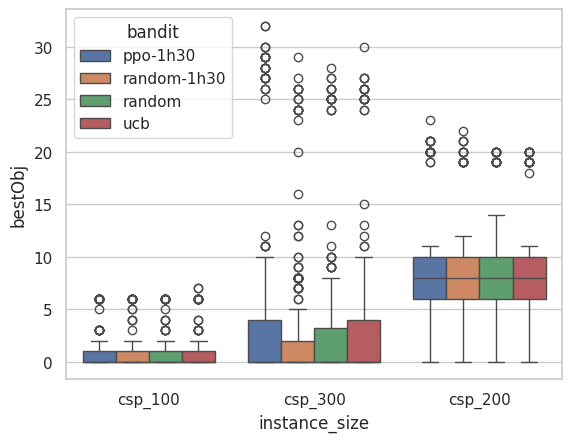

In [3]:
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x="instance_size", y="bestObj", hue="bandit")

Processing ppo-1h30 (1265 results)
Processing random-1h30 (816 results)
Processing ucb (840 results)
Processing random (840 results)


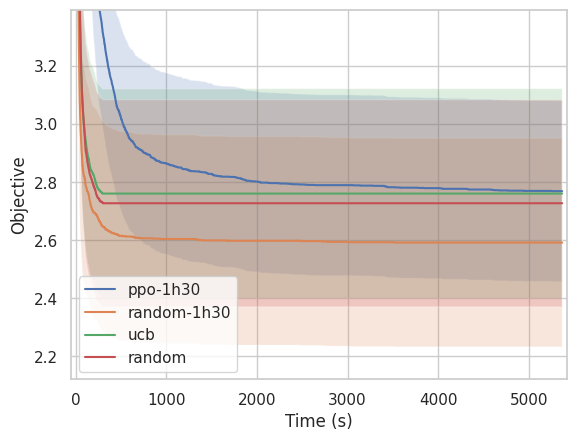

In [4]:
# for (instance_size, *_) , df_instance in df.group_by("instance_size"):
#     plot_by_bandit(df_instance, metric="objective", x_axis="time")
#     plt.title(f"Instance: {instance_size}")
#     #plt.ylim(0, 1)  # For primal gap
#     plt.show()
plot_by_bandit(df, metric="objective", x_axis="time")

Processing ucb (100 results)
Processing random-1h30 (96 results)
Processing ppo-1h30 (150 results)
Processing random (100 results)


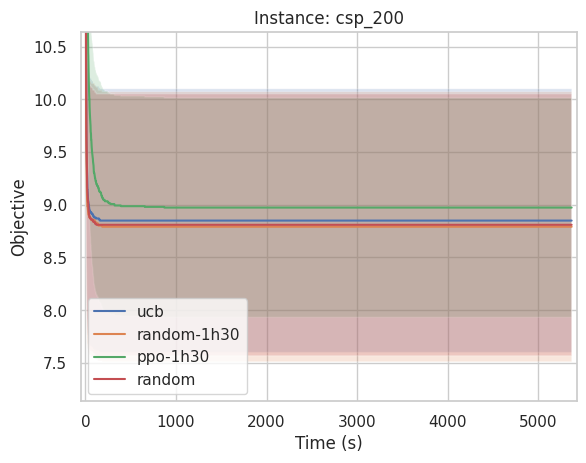

Processing ucb (320 results)
Processing random (320 results)
Processing ppo-1h30 (480 results)
Processing random-1h30 (309 results)


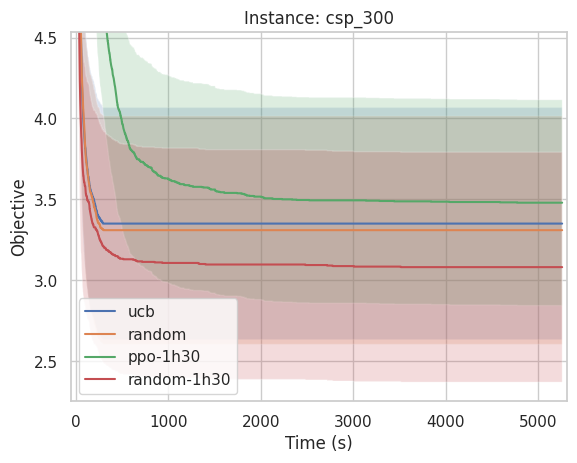

Processing random (420 results)
Processing ppo-1h30 (635 results)
Processing ucb (420 results)
Processing random-1h30 (411 results)


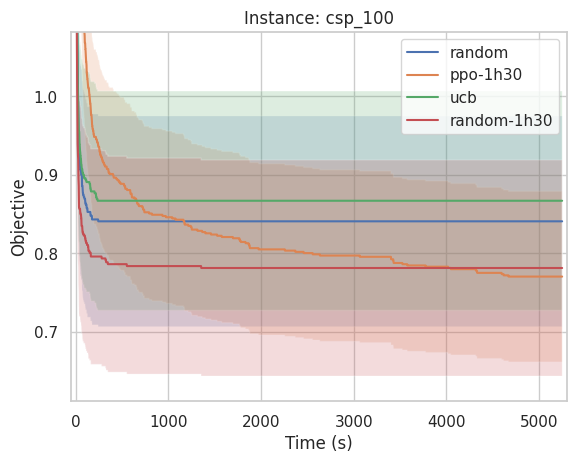

In [6]:
for (instance_size, *_) , df_instance in df.group_by("instance_size"):
    plot_by_bandit(df_instance, metric="objective", x_axis="time")
    plt.title(f"Instance: {instance_size}")
    #plt.ylim(0, 1)  # For primal gap
    plt.show()
